### Determined case ($n=m$)

When the number of neighbors equals the number of constraints,
the system is square:

$A \in \mathbb{R}^{m \times m}$

If $A$ is full rank, there is a unique solution:

$w = A^{-1}b$

Numerically we compute:

$w = A^{+} b$

using the pseudoinverse.  
This case is sensitive to geometry and may become ill-conditioned.

---

### Underdetermined case ($n>m$)

More neighbors than constraints gives infinitely many solutions:

$Aw=b$

We select the minimum-norm solution:

$\min ||w|| \quad \text{s.t. } Aw=b$

The solution is:

$w = A^{+} b$

This regime is the most stable and is commonly used in
meshless and generalized finite difference methods.

---

=== Exact data ===


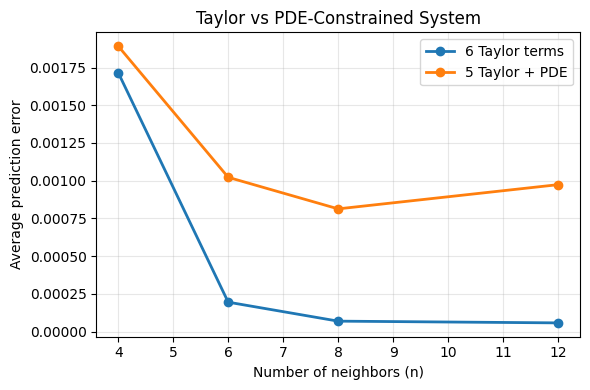

=== Noisy data (2%) ===


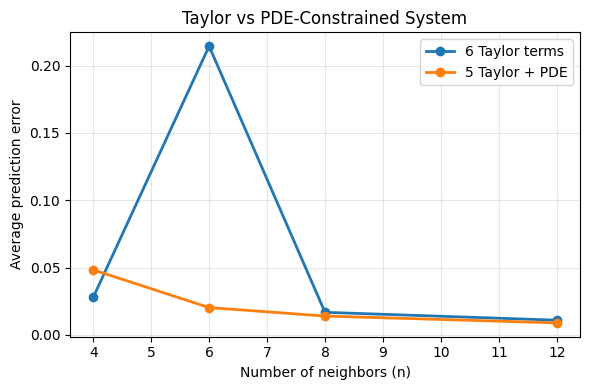

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# TRUE HEAT SOLUTION
# =========================================
def u_true(x, t, alpha=1.0, k=1.0):
    return np.exp(-alpha * k**2 * t) * np.sin(k * x)

# =========================================
# GENERATE RANDOM NEIGHBORS
# =========================================
def generate_neighbors(x_star, t_star, n, radius=0.25):
    xs = x_star + radius * (np.random.rand(n) - 0.5)
    ts = t_star + radius * (np.random.rand(n) - 0.5)
    return xs, ts

# =========================================
# BUILD TAYLOR MATRIX
# =========================================
def build_A(xs, ts, x_star, t_star, num_terms):
    dx = xs - x_star
    dt = ts - t_star

    terms = [
        np.ones_like(dx),  # 1
        dx,
        dt,
        dx**2,
        dx*dt,
        dt**2
    ]

    A = np.vstack(terms[:num_terms])
    return A

def build_b(num_terms):
    b = np.zeros(num_terms)
    b[0] = 1.0
    return b

# =========================================
# PDE CONSTRAINT ROW (heat equation)
# sum w (dt + 0.5 dx^2) = 0
# =========================================
def build_C(xs, ts, x_star, t_star):
    dx = xs - x_star
    dt = ts - t_star
    C = dt + 0.5 * dx**2
    return C.reshape(1, -1)

# =========================================
# ERROR COMPUTATION (with optional noise)
# =========================================
def compute_error(w, xs, ts, x_star, t_star, noise_level=0.0):
    u_vals = u_true(xs, ts)

    if noise_level > 0:
        u_vals = u_vals + noise_level * np.random.randn(len(u_vals))

    u_pred = np.dot(w, u_vals)
    u_exact = u_true(x_star, t_star)

    return abs(u_pred - u_exact)

# =========================================
# MAIN EXPERIMENT
# =========================================
def run_experiment(trials=80, noise_level=0.0):

    x_star = 0.5
    t_star = 0.2

    n_values = [4, 6, 8, 12]

    errors_full = []
    errors_pde = []

    for n in n_values:

        err_full_list = []
        err_pde_list = []

        for _ in range(trials):

            xs, ts = generate_neighbors(x_star, t_star, n)

            # ==========================
            # System A: 6 Taylor terms
            # ==========================
            A_full = build_A(xs, ts, x_star, t_star, 6)
            b_full = build_b(6)

            w_full = np.linalg.pinv(A_full) @ b_full

            err_full = compute_error(
                w_full, xs, ts, x_star, t_star, noise_level
            )

            # ==========================
            # System B: 5 Taylor + PDE
            # ==========================
            A5 = build_A(xs, ts, x_star, t_star, 5)
            b5 = build_b(5)

            C = build_C(xs, ts, x_star, t_star)

            A_aug = np.vstack([A5, C])
            b_aug = np.concatenate([b5, [0.0]])

            w_pde = np.linalg.pinv(A_aug) @ b_aug

            err_pde = compute_error(
                w_pde, xs, ts, x_star, t_star, noise_level
            )

            err_full_list.append(err_full)
            err_pde_list.append(err_pde)

        errors_full.append(np.mean(err_full_list))
        errors_pde.append(np.mean(err_pde_list))

    # =====================================
    # PLOT RESULTS
    # =====================================
    plt.figure(figsize=(6,4))
    plt.plot(n_values, errors_full, marker='o',
             linewidth=2, label="6 Taylor terms")
    plt.plot(n_values, errors_pde, marker='o',
             linewidth=2, label="5 Taylor + PDE")

    plt.xlabel("Number of neighbors (n)")
    plt.ylabel("Average prediction error")
    plt.title("Taylor vs PDE-Constrained System")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# =========================================
# RUN
# =========================================
if __name__ == "__main__":

    print("=== Exact data ===")
    run_experiment(noise_level=0.0)

    print("=== Noisy data (2%) ===")
    run_experiment(noise_level=0.02)

### Overdetermined case ($n<m$)

More constraints than unknowns means $Aw=b$ cannot be satisfied exactly.

We solve the least-squares problem:

$\min_w ||Aw-b||^2$

The solution is:

$w = A^{+} b$

This gives the best approximate weights but may increase error
since not all Taylor constraints can be enforced.

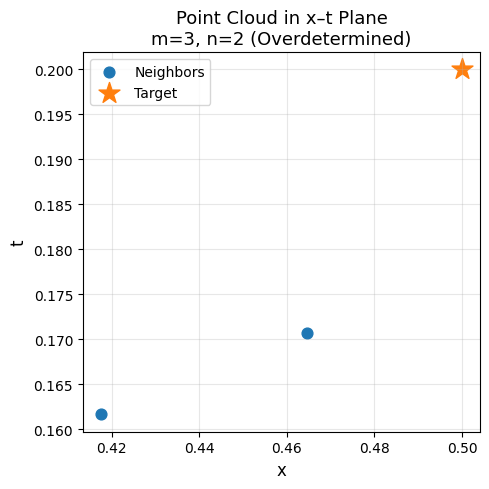

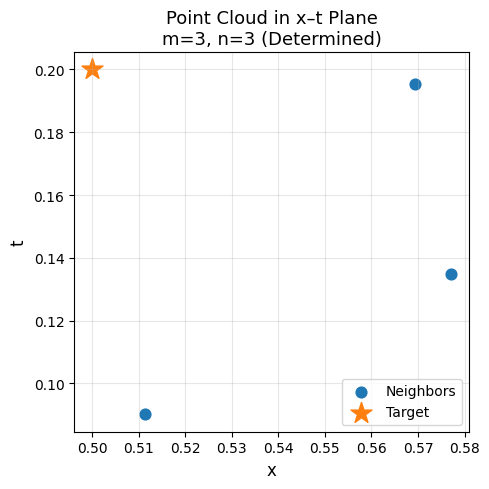

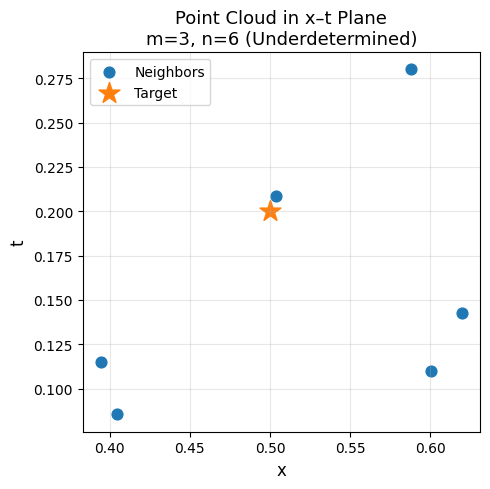

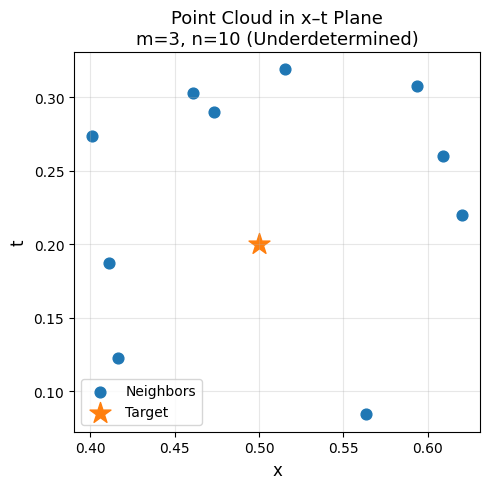

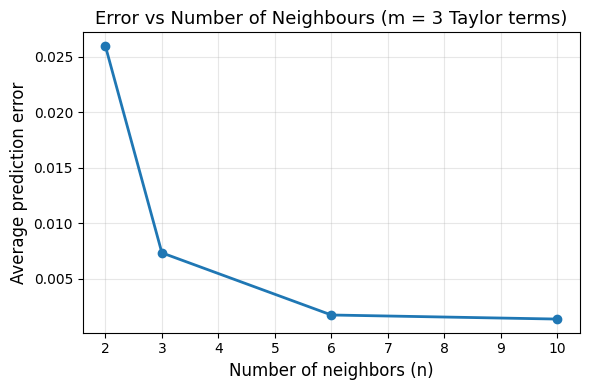

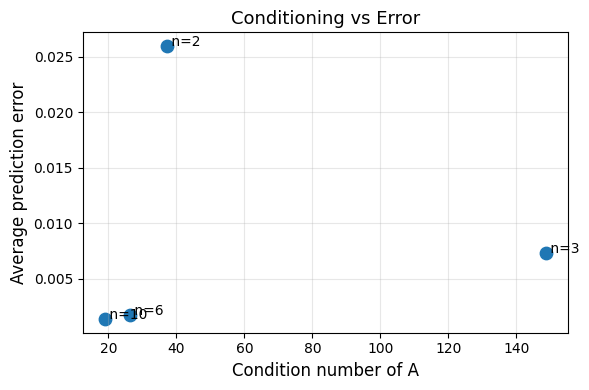

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# TRUE DIFFUSION SOLUTION
# ==============================
def u_true(x, t, alpha=1.0, k=1.0):
    return np.exp(-alpha * k**2 * t) * np.sin(k * x)

# ==============================
# GENERATE NEIGHBOURS
# ==============================
def generate_neighbors(x_star, t_star, n, radius=0.25):
    xs = x_star + radius * (np.random.rand(n) - 0.5)
    ts = t_star + radius * (np.random.rand(n) - 0.5)
    return xs, ts

# ==============================
# BUILD TAYLOR MATRIX
# ==============================
def build_A(xs, ts, x_star, t_star, m):
    dx = xs - x_star
    dt = ts - t_star

    terms = [
        np.ones_like(dx),  # 1
        dx,                # dx
        dt,                # dt
        dx**2,             # dx^2
        dx*dt,             # dx dt
        dt**2              # dt^2
    ]

    if m > len(terms):
        raise ValueError("m too large for implemented Taylor terms")

    A = np.vstack(terms[:m])
    return A

def build_b(m):
    b = np.zeros(m)
    b[0] = 1.0
    return b

# ==============================
# SOLVER (SVD PSEUDOINVERSE)
# ==============================
def solve_weights(A, b):
    w = np.linalg.pinv(A) @ b
    return w

# ==============================
# METRICS
# ==============================
def compute_metrics(A, w, xs, ts, x_star, t_star):
    condA = np.linalg.cond(A)
    norm_w = np.linalg.norm(w)

    u_vals = u_true(xs, ts)
    u_pred = np.dot(w, u_vals)
    u_exact = u_true(x_star, t_star)
    error = abs(u_pred - u_exact)

    return error, condA, norm_w

# ==============================
# REGIME LABEL
# ==============================
def regime_type(m, n):
    if n == m:
        return "Determined"
    elif n > m:
        return "Underdetermined"
    else:
        return "Overdetermined"

# ==============================
# GEOMETRY PLOT
# ==============================
def plot_geometry(xs, ts, x_star, t_star, m, n):
    reg = regime_type(m, n)

    plt.figure(figsize=(5,5))
    plt.scatter(xs, ts, s=60, label="Neighbors")
    plt.scatter([x_star], [t_star], marker="*", s=250, label="Target")

    plt.xlabel("x", fontsize=12)
    plt.ylabel("t", fontsize=12)
    plt.title(f"Point Cloud in x–t Plane\nm={m}, n={n} ({reg})", fontsize=13)

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==============================
# MAIN COMPARISON EXPERIMENT


    C = dt + 0.5 * dx**2
    return C.reshape(1, -1)
def run_comparison(m=3, trials=50):
    x_star = 0.5
    t_star = 0.2

    n_values = [m-1, m, m+3, m+7]  # over, determined, under, more under

    avg_errors = []
    avg_conds = []

    for n in n_values:
        errors = []
        conds = []

        for _ in range(trials):
            xs, ts = generate_neighbors(x_star, t_star, n)

            A = build_A(xs, ts, x_star, t_star, m)
            b = build_b(m)

            w = solve_weights(A, b)
            error, condA, norm_w = compute_metrics(A, w, xs, ts, x_star, t_star)

            errors.append(error)
            conds.append(condA)

        avg_errors.append(np.mean(errors))
        avg_conds.append(np.mean(conds))

        # Plot one geometry example per regime
        xs, ts = generate_neighbors(x_star, t_star, n)
        plot_geometry(xs, ts, x_star, t_star, m, n)

    # ==============================
    # PLOT 1: Error vs n
    # ==============================
    plt.figure(figsize=(6,4))
    plt.plot(n_values, avg_errors, marker='o', linewidth=2)

    plt.xlabel("Number of neighbors (n)", fontsize=12)
    plt.ylabel("Average prediction error", fontsize=12)
    plt.title(f"Error vs Number of Neighbours (m = {m} Taylor terms)", fontsize=13)

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    # ==============================
    # PLOT 2: Condition vs error
    # ==============================
    plt.figure(figsize=(6,4))
    plt.scatter(avg_conds, avg_errors, s=80)
    for i, n in enumerate(n_values):
        plt.text(avg_conds[i], avg_errors[i], f" n={n}")

    plt.xlabel("Condition number of A", fontsize=12)
    plt.ylabel("Average prediction error", fontsize=12)
    plt.title("Conditioning vs Error", fontsize=13)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ==============================
# RUN
# ==============================
if __name__ == "__main__":
    run_comparison(m=3, trials=60)

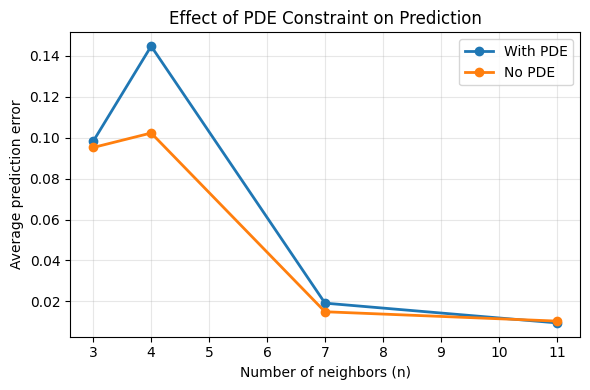

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# TRUE HEAT SOLUTION (exact PDE solution)
# =========================================
def u_true(x, t, alpha=1.0, k=1.0):
    return np.exp(-alpha * k**2 * t) * np.sin(k * x)

# =========================================
# GENERATE RANDOM NEIGHBORS
# =========================================
def generate_neighbors(x_star, t_star, n, radius=0.25):
    xs = x_star + radius * (np.random.rand(n) - 0.5)
    ts = t_star + radius * (np.random.rand(n) - 0.5)
    return xs, ts

# =========================================
# BUILD TAYLOR MATRIX
# =========================================
def build_A(xs, ts, x_star, t_star, m):
    dx = xs - x_star
    dt = ts - t_star

    terms = [
        np.ones_like(dx),  # 1
        dx,                # dx
        dt,                # dt
        dx**2,             # dx^2
        dx*dt,             # dx dt
        dt**2              # dt^2

    ]

    if m > len(terms):
        raise ValueError("m too large")

    A = np.vstack(terms[:m])
    return A

def build_b(m):
    b = np.zeros(m)
    b[0] = 1.0
    return b

# =========================================
# PDE CONSTRAINT ROW
# heat: u_t = u_xx
# sum w (dt + 0.5 dx^2) = 0
# =========================================
def build_C(xs, ts, x_star, t_star):
    dx = xs - x_star
    dt = ts - t_star
    C = dt + 0.5 * dx**2
    return C.reshape(1, -1)

# =========================================
# SOLVERS
# =========================================
def solve_standard(A, b):
    return np.linalg.pinv(A) @ b

def solve_with_pde(A, b, C):
    A_aug = np.vstack([A, C])
    b_aug = np.concatenate([b, [0.0]])
    return np.linalg.pinv(A_aug) @ b_aug

# =========================================
# ERROR + METRICS
# =========================================
def compute_error(w, xs, ts, x_star, t_star, noise=0.02):
    u_vals = u_true(xs, ts)

    # add noise
    u_vals = u_vals + noise*np.random.randn(len(u_vals))

    u_pred = np.dot(w, u_vals)
    u_exact = u_true(x_star, t_star)
    return abs(u_pred - u_exact)

# =========================================
# MAIN EXPERIMENT
# =========================================
def run_experiment(m=4, trials=80):

    x_star = 0.5
    t_star = 0.2

    n_values = [m-1, m, m+3, m+7]

    err_std_all = []
    err_pde_all = []

    for n in n_values:

        errs_std = []
        errs_pde = []

        for _ in range(trials):

            xs, ts = generate_neighbors(x_star, t_star, n)

            A = build_A(xs, ts, x_star, t_star, m)
            b = build_b(m)

            # standard
            w_std = solve_standard(A, b)

            # with PDE
            C = build_C(xs, ts, x_star, t_star)
            w_pde = solve_with_pde(A, b, C)

            err_std = compute_error(w_std, xs, ts, x_star, t_star)
            err_pde = compute_error(w_pde, xs, ts, x_star, t_star)

            errs_std.append(err_std)
            errs_pde.append(err_pde)

        err_std_all.append(np.mean(errs_std))
        err_pde_all.append(np.mean(errs_pde))

    # =====================================
    # PLOT COMPARISON
    # =====================================
    plt.figure(figsize=(6,4))
    plt.plot(n_values, err_pde_all, marker='o', label="With PDE", linewidth=2)
    plt.plot(n_values, err_std_all, marker='o', label="No PDE", linewidth=2)


    plt.xlabel("Number of neighbors (n)")
    plt.ylabel("Average prediction error")
    plt.title("Effect of PDE Constraint on Prediction")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# =========================================
# RUN
# =========================================
if __name__ == "__main__":
    run_experiment()

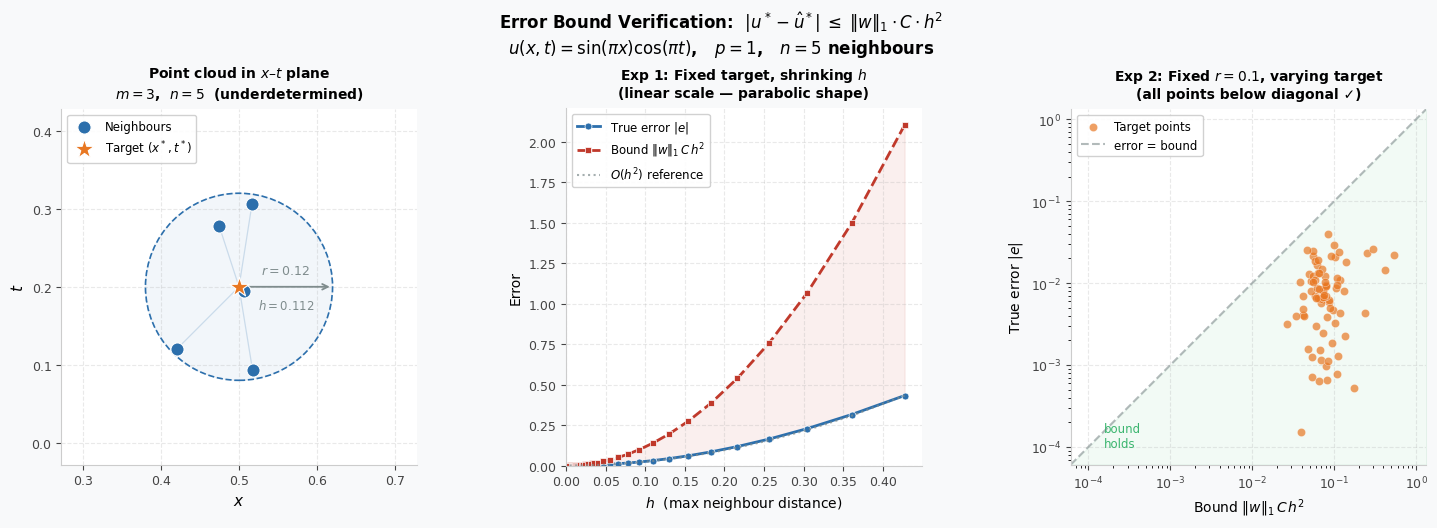

Max ratio |e|/bound : 0.5489
All below bound     : True


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─────────────────────────────────────────────
# Test function: u(x,t) = sin(πx)cos(πt)
# ─────────────────────────────────────────────
def u(x, t):     return np.sin(np.pi * x) * np.cos(np.pi * t)
def u_xx(x, t):  return -(np.pi**2) * np.sin(np.pi * x) * np.cos(np.pi * t)
def u_xt(x, t):  return  (np.pi**2) * np.sin(np.pi * x) * np.sin(np.pi * t)
def u_tt(x, t):  return -(np.pi**2) * np.sin(np.pi * x) * np.cos(np.pi * t)

def C_bound(x, t):
    return max(abs(u_xx(x, t)), abs(u_xt(x, t)), abs(u_tt(x, t)))

def compute_weights(dx, dt):
    A = np.vstack([np.ones(len(dx)), dx, dt])
    b = np.array([1.0, 0.0, 0.0])
    w, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    return w

def get_neighbours(r, n=5, rng=None, cond_threshold=1e6):
    if rng is None:
        rng = np.random.default_rng()
    for _ in range(200):
        angles = rng.uniform(0, 2 * np.pi, n)
        radii  = r * np.sqrt(rng.uniform(0, 1, n))
        dx = radii * np.cos(angles)
        dt = radii * np.sin(angles)
        A  = np.vstack([np.ones(n), dx, dt])
        if np.linalg.cond(A) < cond_threshold:
            h = np.max(np.sqrt(dx**2 + dt**2))
            return dx, dt, h
    h = np.max(np.sqrt(dx**2 + dt**2))
    return dx, dt, h

# ─────────────────────────────────────────────
# Experiment 1: Fixed target, shrink r
# Fix direction pattern, only scale r → clean O(h^2)
# ─────────────────────────────────────────────
x_star, t_star = 0.5, 0.3

rng_dirs     = np.random.default_rng(99)
angles_fixed = rng_dirs.uniform(0, 2 * np.pi, 5)
frac_fixed   = np.sqrt(rng_dirs.uniform(0.3, 1.0, 5))

r_values = np.logspace(-0.3, -15, 200)
errors_h, bounds_h, h_used = [], [], []

for r in r_values:
    dx_arr = r * frac_fixed * np.cos(angles_fixed)
    dt_arr = r * frac_fixed * np.sin(angles_fixed)
    h = np.max(np.sqrt(dx_arr**2 + dt_arr**2))
    w      = compute_weights(dx_arr, dt_arr)
    u_pred = w @ u(x_star + dx_arr, t_star + dt_arr)
    error  = abs(u(x_star, t_star) - u_pred)
    bound  = np.sum(np.abs(w)) * C_bound(x_star, t_star) * h**2
    errors_h.append(error)
    bounds_h.append(bound)
    h_used.append(h)

errors_h = np.array(errors_h)
bounds_h = np.array(bounds_h)
h_used   = np.array(h_used)

# ─────────────────────────────────────────────
# Experiment 2: Fixed r, vary target point
# ─────────────────────────────────────────────
r_fixed   = 0.1
rng2      = np.random.default_rng(42)
n_pts     = 80
x_targets = rng2.uniform(0.2, 0.8, n_pts)
t_targets = rng2.uniform(0.2, 0.8, n_pts)
errors_pts, bounds_pts = [], []

for xs, ts in zip(x_targets, t_targets):
    dx_arr, dt_arr, h = get_neighbours(r_fixed, rng=rng2)
    w      = compute_weights(dx_arr, dt_arr)
    u_pred = w @ u(xs + dx_arr, ts + dt_arr)
    error  = abs(u(xs, ts) - u_pred)
    bound  = np.sum(np.abs(w)) * C_bound(xs, ts) * h**2
    errors_pts.append(error)
    bounds_pts.append(bound)

errors_pts = np.array(errors_pts)
bounds_pts = np.array(bounds_pts)

# ─────────────────────────────────────────────
# Demo point cloud (panel 1)
# ─────────────────────────────────────────────
x_demo, t_demo = 0.5, 0.2
r_demo = 0.12
dx_demo, dt_demo, h_actual = get_neighbours(r_demo, rng=np.random.default_rng(7))
x_nbrs = x_demo + dx_demo
t_nbrs = t_demo + dt_demo

# ─────────────────────────────────────────────
# Plotting
# ─────────────────────────────────────────────
BLUE   = '#2C6FAC'
ORANGE = '#E87722'
RED    = '#C0392B'
GREEN  = '#27AE60'
GREY   = '#7F8C8D'

def style_ax(ax):
    ax.set_facecolor('white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#CCCCCC')
    ax.tick_params(colors='#444444', labelsize=9)
    ax.grid(True, alpha=0.25, linestyle='--', color='#AAAAAA')

fig = plt.figure(figsize=(15, 5.5))
fig.patch.set_facecolor('#F8F9FA')
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.42,
                        left=0.06, right=0.97, top=0.78, bottom=0.13)

# ── Panel 1: Point cloud ──────────────────────────────────
ax1 = fig.add_subplot(gs[0])
style_ax(ax1)

circle      = plt.Circle((x_demo, t_demo), r_demo, color=BLUE, fill=True,  alpha=0.06, zorder=1)
circle_edge = plt.Circle((x_demo, t_demo), r_demo, color=BLUE, fill=False,
                          linestyle='--', linewidth=1.2, zorder=2)
ax1.add_patch(circle)
ax1.add_patch(circle_edge)

for xn, tn in zip(x_nbrs, t_nbrs):
    ax1.plot([x_demo, xn], [t_demo, tn], color=BLUE, alpha=0.2, linewidth=0.9, zorder=2)

ax1.scatter(x_nbrs, t_nbrs, s=90, color=BLUE, zorder=4,
            edgecolors='white', linewidths=0.8, label='Neighbours')
ax1.scatter(x_demo, t_demo, s=220, color=ORANGE, marker='*', zorder=5,
            edgecolors='white', linewidths=0.8, label='Target $(x^*, t^*)$')

ax1.annotate('', xy=(x_demo + r_demo, t_demo), xytext=(x_demo, t_demo),
             arrowprops=dict(arrowstyle='->', color=GREY, lw=1.3))
ax1.text(x_demo + r_demo/2, t_demo + 0.013, f'$r={r_demo}$',
         ha='center', va='bottom', fontsize=9, color=GREY)
ax1.text(x_demo + r_demo/2, t_demo - 0.015, f'$h={h_actual:.3f}$',
         ha='center', va='top', fontsize=8.5, color=GREY, style='italic')

ax1.set_xlabel('$x$', fontsize=11)
ax1.set_ylabel('$t$', fontsize=11)
ax1.set_title('Point cloud in $x$–$t$ plane\n$m=3$,  $n=5$  (underdetermined)',
              fontsize=10, fontweight='bold', pad=8)
ax1.legend(fontsize=8.5, framealpha=0.9, edgecolor='#CCCCCC', loc='upper left')
margin = 1.9 * r_demo
ax1.set_xlim(x_demo - margin, x_demo + margin)
ax1.set_ylim(t_demo - margin, t_demo + margin)
ax1.set_aspect('equal')

# ── Panel 2: Error vs h log-log ───────────────────────────
ax2 = fig.add_subplot(gs[1])
style_ax(ax2)

ax2.plot(h_used, errors_h, 'o-', color=BLUE, label='True error $|e|$',
         linewidth=2, markersize=5, markeredgecolor='white', markeredgewidth=0.5)
ax2.plot(h_used, bounds_h, 's--', color=RED,
         label=r'Bound $\|w\|_1\,C\,h^2$', linewidth=2, markersize=5,
         markeredgecolor='white', markeredgewidth=0.5)
ref = errors_h[0] / h_used[0]**2 * h_used**2
ax2.plot(h_used, ref, ':', color=GREY, alpha=0.7, label=r'$O(h^2)$ reference')
ax2.fill_between(h_used, errors_h, bounds_h, alpha=0.08, color=RED)

ax2.set_xlabel('$h$  (max neighbour distance)', fontsize=10)
ax2.set_ylabel('Error', fontsize=10)
ax2.set_title('Exp 1: Fixed target, shrinking $h$\n(linear scale — parabolic shape)',
              fontsize=10, fontweight='bold', pad=8)
ax2.legend(fontsize=8.5, framealpha=0.9, edgecolor='#CCCCCC')
ax2.set_xlim(left=0)
ax2.set_ylim(bottom=0)

# ── Panel 3: Error vs Bound scatter ───────────────────────
ax3 = fig.add_subplot(gs[2])
style_ax(ax3)

ax3.scatter(bounds_pts, errors_pts, color=ORANGE, alpha=0.7, s=35,
            edgecolors='white', linewidths=0.3, label='Target points', zorder=3)

all_vals = np.concatenate([bounds_pts, errors_pts])
lims = [all_vals.min() * 0.4, all_vals.max() * 2.5]
ax3.plot(lims, lims, '--', color=GREY, alpha=0.6, linewidth=1.5,
         label='error = bound', zorder=2)
ax3.fill_between(lims, [lims[0]]*2, lims, alpha=0.06, color=GREEN)
ax3.text(lims[0]*2.5, lims[0]*1.5, 'bound\nholds',
         fontsize=8.5, color=GREEN, alpha=0.9, va='bottom')

ax3.set_xlim(lims); ax3.set_ylim(lims)
ax3.set_xscale('log'); ax3.set_yscale('log')
ax3.set_xlabel(r'Bound $\|w\|_1\,C\,h^2$', fontsize=10)
ax3.set_ylabel(r'True error $|e|$', fontsize=10)
ax3.set_title(f'Exp 2: Fixed $r={r_fixed}$, varying target\n(all points below diagonal ✓)',
              fontsize=10, fontweight='bold', pad=8)
ax3.legend(fontsize=8.5, framealpha=0.9, edgecolor='#CCCCCC')
ax3.set_aspect('equal')

fig.suptitle(
    r'Error Bound Verification:  $|u^* - \hat{u}^*|\;\leq\;\|w\|_1\cdot C\cdot h^2$'
    '\n'
    r'$u(x,t)=\sin(\pi x)\cos(\pi t)$,   $p=1$,   $n=5$ neighbours',
    fontsize=12, fontweight='bold', y=0.96
)

plt.savefig('error_bound_verification.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"Max ratio |e|/bound : {(errors_pts/bounds_pts).max():.4f}")
print(f"All below bound     : {np.all(errors_pts <= bounds_pts)}")

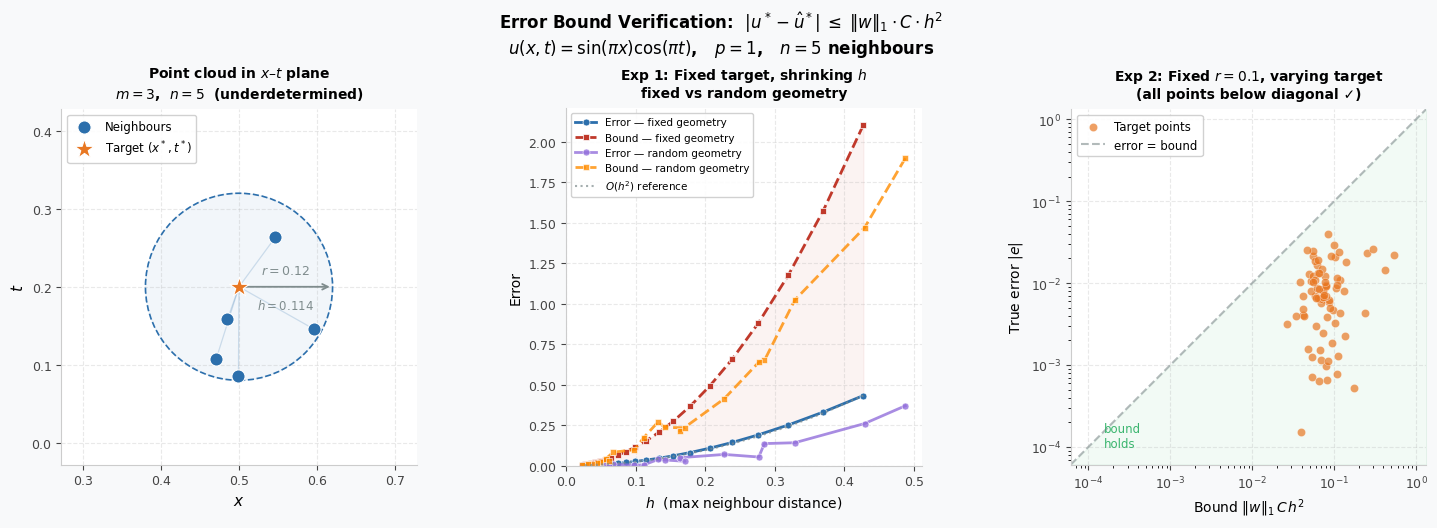

Max ratio |e|/bound : 0.5489
All below bound     : True


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─────────────────────────────────────────────
# Test function: u(x,t) = sin(πx)cos(πt)
# ─────────────────────────────────────────────
def u(x, t):     return np.sin(np.pi * x) * np.cos(np.pi * t)
def u_xx(x, t):  return -(np.pi**2) * np.sin(np.pi * x) * np.cos(np.pi * t)
def u_xt(x, t):  return  (np.pi**2) * np.sin(np.pi * x) * np.sin(np.pi * t)
def u_tt(x, t):  return -(np.pi**2) * np.sin(np.pi * x) * np.cos(np.pi * t)

def C_bound(x, t):
    return max(abs(u_xx(x, t)), abs(u_xt(x, t)), abs(u_tt(x, t)))

def compute_weights(dx, dt):
    A = np.vstack([np.ones(len(dx)), dx, dt])
    b = np.array([1.0, 0.0, 0.0])
    w, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    return w

def get_neighbours(r, n=5, rng=None, cond_threshold=1e6):
    if rng is None:
        rng = np.random.default_rng()
    for _ in range(200):
        angles = rng.uniform(0, 2 * np.pi, n)
        radii  = r * np.sqrt(rng.uniform(0, 1, n))
        dx = radii * np.cos(angles)
        dt = radii * np.sin(angles)
        A  = np.vstack([np.ones(n), dx, dt])
        if np.linalg.cond(A) < cond_threshold:
            h = np.max(np.sqrt(dx**2 + dt**2))
            return dx, dt, h
    h = np.max(np.sqrt(dx**2 + dt**2))
    return dx, dt, h

# ─────────────────────────────────────────────
# Experiment 1: Fixed target, shrink r
# Fix direction pattern, only scale r → clean O(h^2)
# ─────────────────────────────────────────────
x_star, t_star = 0.5, 0.3

rng_dirs     = np.random.default_rng(99)
angles_fixed = rng_dirs.uniform(0, 2 * np.pi, 5)
frac_fixed   = np.sqrt(rng_dirs.uniform(0.3, 1.0, 5))

r_values = np.logspace(-0.3, -1.5, 20)

# Version A: fixed directions, only scale r
errors_h, bounds_h, h_used = [], [], []
for r in r_values:
    dx_arr = r * frac_fixed * np.cos(angles_fixed)
    dt_arr = r * frac_fixed * np.sin(angles_fixed)
    h = np.max(np.sqrt(dx_arr**2 + dt_arr**2))
    w      = compute_weights(dx_arr, dt_arr)
    u_pred = w @ u(x_star + dx_arr, t_star + dt_arr)
    error  = abs(u(x_star, t_star) - u_pred)
    bound  = np.sum(np.abs(w)) * C_bound(x_star, t_star) * h**2
    errors_h.append(error)
    bounds_h.append(bound)
    h_used.append(h)

errors_h = np.array(errors_h)
bounds_h = np.array(bounds_h)
h_used   = np.array(h_used)

# Version B: fresh random directions at each r
rng_rand = np.random.default_rng(55)
errors_h_rand, bounds_h_rand, h_used_rand = [], [], []
for r in r_values:
    dx_arr, dt_arr, h = get_neighbours(r, rng=rng_rand)
    w      = compute_weights(dx_arr, dt_arr)
    u_pred = w @ u(x_star + dx_arr, t_star + dt_arr)
    error  = abs(u(x_star, t_star) - u_pred)
    bound  = np.sum(np.abs(w)) * C_bound(x_star, t_star) * h**2
    errors_h_rand.append(error)
    bounds_h_rand.append(bound)
    h_used_rand.append(h)

errors_h_rand = np.array(errors_h_rand)
bounds_h_rand = np.array(bounds_h_rand)
h_used_rand   = np.array(h_used_rand)

# ─────────────────────────────────────────────
# Experiment 2: Fixed r, vary target point
# ─────────────────────────────────────────────
r_fixed   = 0.1
rng2      = np.random.default_rng(42)
n_pts     = 80
x_targets = rng2.uniform(0.2, 0.8, n_pts)
t_targets = rng2.uniform(0.2, 0.8, n_pts)
errors_pts, bounds_pts = [], []

for xs, ts in zip(x_targets, t_targets):
    dx_arr, dt_arr, h = get_neighbours(r_fixed, rng=rng2)
    w      = compute_weights(dx_arr, dt_arr)
    u_pred = w @ u(xs + dx_arr, ts + dt_arr)
    error  = abs(u(xs, ts) - u_pred)
    bound  = np.sum(np.abs(w)) * C_bound(xs, ts) * h**2
    errors_pts.append(error)
    bounds_pts.append(bound)

errors_pts = np.array(errors_pts)
bounds_pts = np.array(bounds_pts)

# ─────────────────────────────────────────────
# Demo point cloud (panel 1)
# ─────────────────────────────────────────────
x_demo, t_demo = 0.5, 0.2
r_demo = 0.12
dx_demo, dt_demo, h_actual = get_neighbours(r_demo)
x_nbrs = x_demo + dx_demo
t_nbrs = t_demo + dt_demo

# ─────────────────────────────────────────────
# Plotting
# ─────────────────────────────────────────────
BLUE   = '#2C6FAC'
ORANGE = '#E87722'
RED    = '#C0392B'
GREEN  = '#27AE60'
GREY   = '#7F8C8D'

def style_ax(ax):
    ax.set_facecolor('white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#CCCCCC')
    ax.tick_params(colors='#444444', labelsize=9)
    ax.grid(True, alpha=0.25, linestyle='--', color='#AAAAAA')

fig = plt.figure(figsize=(15, 5.5))
fig.patch.set_facecolor('#F8F9FA')
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.42,
                        left=0.06, right=0.97, top=0.78, bottom=0.13)

# ── Panel 1: Point cloud ──────────────────────────────────
ax1 = fig.add_subplot(gs[0])
style_ax(ax1)

circle      = plt.Circle((x_demo, t_demo), r_demo, color=BLUE, fill=True,  alpha=0.06, zorder=1)
circle_edge = plt.Circle((x_demo, t_demo), r_demo, color=BLUE, fill=False,
                          linestyle='--', linewidth=1.2, zorder=2)
ax1.add_patch(circle)
ax1.add_patch(circle_edge)

for xn, tn in zip(x_nbrs, t_nbrs):
    ax1.plot([x_demo, xn], [t_demo, tn], color=BLUE, alpha=0.2, linewidth=0.9, zorder=2)

ax1.scatter(x_nbrs, t_nbrs, s=90, color=BLUE, zorder=4,
            edgecolors='white', linewidths=0.8, label='Neighbours')
ax1.scatter(x_demo, t_demo, s=220, color=ORANGE, marker='*', zorder=5,
            edgecolors='white', linewidths=0.8, label='Target $(x^*, t^*)$')

ax1.annotate('', xy=(x_demo + r_demo, t_demo), xytext=(x_demo, t_demo),
             arrowprops=dict(arrowstyle='->', color=GREY, lw=1.3))
ax1.text(x_demo + r_demo/2, t_demo + 0.013, f'$r={r_demo}$',
         ha='center', va='bottom', fontsize=9, color=GREY)
ax1.text(x_demo + r_demo/2, t_demo - 0.015, f'$h={h_actual:.3f}$',
         ha='center', va='top', fontsize=8.5, color=GREY, style='italic')

ax1.set_xlabel('$x$', fontsize=11)
ax1.set_ylabel('$t$', fontsize=11)
ax1.set_title('Point cloud in $x$–$t$ plane\n$m=3$,  $n=5$  (underdetermined)',
              fontsize=10, fontweight='bold', pad=8)
ax1.legend(fontsize=8.5, framealpha=0.9, edgecolor='#CCCCCC', loc='upper left')
margin = 1.9 * r_demo
ax1.set_xlim(x_demo - margin, x_demo + margin)
ax1.set_ylim(t_demo - margin, t_demo + margin)
ax1.set_aspect('equal')

# ── Panel 2: Error vs h log-log ───────────────────────────
ax2 = fig.add_subplot(gs[1])
style_ax(ax2)

ax2.plot(h_used, errors_h, 'o-', color=BLUE, label='Error — fixed geometry',
         linewidth=2, markersize=5, markeredgecolor='white', markeredgewidth=0.5)
ax2.plot(h_used, bounds_h, 's--', color=RED,
         label=r'Bound — fixed geometry', linewidth=2, markersize=5,
         markeredgecolor='white', markeredgewidth=0.5)
ax2.plot(h_used_rand, errors_h_rand, 'o-', color='mediumpurple',
         label='Error — random geometry', linewidth=2, markersize=5,
         markeredgecolor='white', markeredgewidth=0.5, alpha=0.8)
ax2.plot(h_used_rand, bounds_h_rand, 's--', color='darkorange',
         label=r'Bound — random geometry', linewidth=2, markersize=5,
         markeredgecolor='white', markeredgewidth=0.5, alpha=0.8)
ref = errors_h[0] / h_used[0]**2 * h_used**2
ax2.plot(h_used, ref, ':', color=GREY, alpha=0.7, label=r'$O(h^2)$ reference')
ax2.fill_between(h_used, errors_h, bounds_h, alpha=0.06, color=RED)

ax2.set_xlabel('$h$  (max neighbour distance)', fontsize=10)
ax2.set_ylabel('Error', fontsize=10)
ax2.set_title('Exp 1: Fixed target, shrinking $h$\nfixed vs random geometry',
              fontsize=10, fontweight='bold', pad=8)
ax2.legend(fontsize=7.5, framealpha=0.9, edgecolor='#CCCCCC')
ax2.set_xlim(left=0)
ax2.set_ylim(bottom=0)

# ── Panel 3: Error vs Bound scatter ───────────────────────
ax3 = fig.add_subplot(gs[2])
style_ax(ax3)

ax3.scatter(bounds_pts, errors_pts, color=ORANGE, alpha=0.7, s=35,
            edgecolors='white', linewidths=0.3, label='Target points', zorder=3)

all_vals = np.concatenate([bounds_pts, errors_pts])
lims = [all_vals.min() * 0.4, all_vals.max() * 2.5]
ax3.plot(lims, lims, '--', color=GREY, alpha=0.6, linewidth=1.5,
         label='error = bound', zorder=2)
ax3.fill_between(lims, [lims[0]]*2, lims, alpha=0.06, color=GREEN)
ax3.text(lims[0]*2.5, lims[0]*1.5, 'bound\nholds',
         fontsize=8.5, color=GREEN, alpha=0.9, va='bottom')

ax3.set_xlim(lims); ax3.set_ylim(lims)
ax3.set_xscale('log'); ax3.set_yscale('log')
ax3.set_xlabel(r'Bound $\|w\|_1\,C\,h^2$', fontsize=10)
ax3.set_ylabel(r'True error $|e|$', fontsize=10)
ax3.set_title(f'Exp 2: Fixed $r={r_fixed}$, varying target\n(all points below diagonal ✓)',
              fontsize=10, fontweight='bold', pad=8)
ax3.legend(fontsize=8.5, framealpha=0.9, edgecolor='#CCCCCC')
ax3.set_aspect('equal')

fig.suptitle(
    r'Error Bound Verification:  $|u^* - \hat{u}^*|\;\leq\;\|w\|_1\cdot C\cdot h^2$'
    '\n'
    r'$u(x,t)=\sin(\pi x)\cos(\pi t)$,   $p=1$,   $n=5$ neighbours',
    fontsize=12, fontweight='bold', y=0.96
)

plt.savefig('error_bound_verification.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"Max ratio |e|/bound : {(errors_pts/bounds_pts).max():.4f}")
print(f"All below bound     : {np.all(errors_pts <= bounds_pts)}")

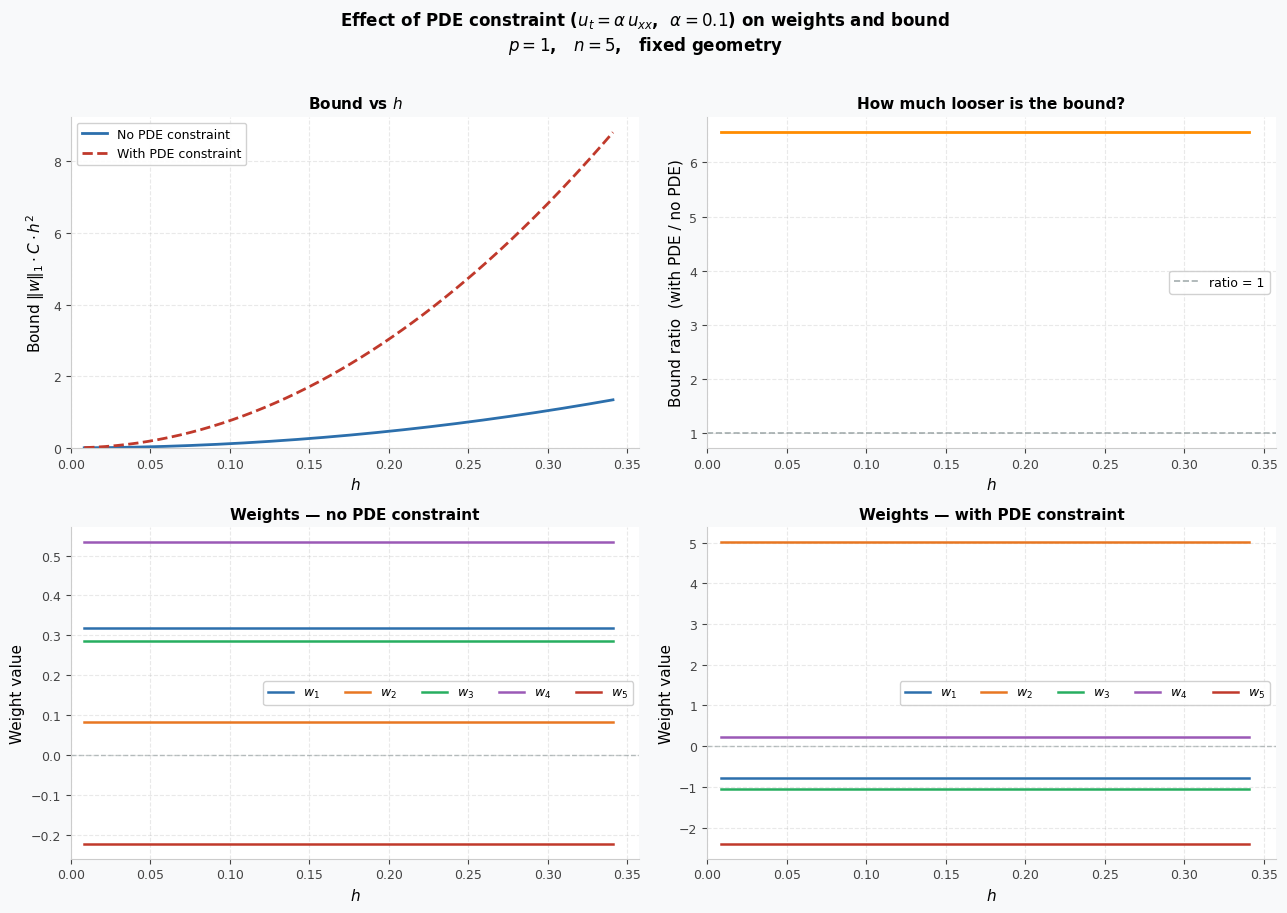

Mean ratio (with/without PDE): 6.5709
Max  ratio (with/without PDE): 6.5709


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────
alpha = 0.1   # diffusion coefficient in u_t = alpha * u_xx

# Test function: u(x,t) = sin(πx)cos(πt)
def u_xx(x, t): return -(np.pi**2) * np.sin(np.pi * x) * np.cos(np.pi * t)
def u_xt(x, t): return  (np.pi**2) * np.sin(np.pi * x) * np.sin(np.pi * t)
def u_tt(x, t): return -(np.pi**2) * np.sin(np.pi * x) * np.cos(np.pi * t)

def C_bound(x, t):
    return max(abs(u_xx(x, t)), abs(u_xt(x, t)), abs(u_tt(x, t)))

# ─────────────────────────────────────────────
# Weight solvers
# ─────────────────────────────────────────────
def weights_no_pde(dx, dt):
    """Minimum-norm solution with 3 Taylor constraints."""
    A = np.vstack([np.ones(len(dx)), dx, dt])
    b = np.array([1.0, 0.0, 0.0])
    w, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    return w

def weights_with_pde(dx, dt, alpha):
    """Minimum-norm solution with 3 Taylor + 1 PDE constraint."""
    A = np.vstack([
        np.ones(len(dx)),
        dx,
        dt,
        dt - alpha * dx**2        # PDE row: Δt_i - α Δx_i²
    ])
    b = np.array([1.0, 0.0, 0.0, 0.0])
    w, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    return w

# ─────────────────────────────────────────────
# Neighbour sampling (fixed directions, scale r)
# ─────────────────────────────────────────────
rng = np.random.default_rng(99)
angles_fixed = rng.uniform(0, 2 * np.pi, 5)
frac_fixed   = np.sqrt(rng.uniform(0.3, 1.0, 5))

def get_neighbours_fixed(r):
    dx = r * frac_fixed * np.cos(angles_fixed)
    dt = r * frac_fixed * np.sin(angles_fixed)
    h  = np.max(np.sqrt(dx**2 + dt**2))
    return dx, dt, h

# ─────────────────────────────────────────────
# Compute bounds over range of r values
# ─────────────────────────────────────────────
x_star, t_star = 0.5, 0.3
C = C_bound(x_star, t_star)

r_values = np.linspace(0.01, 0.4, 200)
bounds_no_pde   = []
bounds_with_pde = []
h_values        = []
w1_all          = []
w2_all          = []

for r in r_values:
    dx, dt, h = get_neighbours_fixed(r)

    w1 = weights_no_pde(dx, dt)
    w2 = weights_with_pde(dx, dt, alpha)

    bounds_no_pde.append(np.sum(np.abs(w1)) * C * h**2)
    bounds_with_pde.append(np.sum(np.abs(w2)) * C * h**2)
    h_values.append(h)
    w1_all.append(w1)
    w2_all.append(w2)

bounds_no_pde   = np.array(bounds_no_pde)
bounds_with_pde = np.array(bounds_with_pde)
h_values        = np.array(h_values)
w1_all          = np.array(w1_all)   # shape (200, 5)
w2_all          = np.array(w2_all)   # shape (200, 5)

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────
BLUE   = '#2C6FAC'
RED    = '#C0392B'
GREY   = '#7F8C8D'
COLORS = ['#2C6FAC','#E87722','#27AE60','#9B59B6','#C0392B']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.patch.set_facecolor('#F8F9FA')

def style_ax(ax):
    ax.set_facecolor('white')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#CCCCCC')
    ax.tick_params(colors='#444444', labelsize=9)
    ax.grid(True, alpha=0.25, linestyle='--', color='#AAAAAA')

for ax in axes.flat:
    style_ax(ax)

# ── Top left: bound vs h ──────────────────────
axes[0,0].plot(h_values, bounds_no_pde, '-', color=BLUE,
               linewidth=2, label='No PDE constraint')
axes[0,0].plot(h_values, bounds_with_pde, '--', color=RED,
               linewidth=2, label='With PDE constraint')
axes[0,0].set_xlabel('$h$', fontsize=11)
axes[0,0].set_ylabel(r'Bound $\|w\|_1 \cdot C \cdot h^2$', fontsize=11)
axes[0,0].set_title('Bound vs $h$', fontsize=11, fontweight='bold')
axes[0,0].legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC')
axes[0,0].set_xlim(left=0); axes[0,0].set_ylim(bottom=0)

# ── Top right: ratio ──────────────────────────
ratio = bounds_with_pde / bounds_no_pde
axes[0,1].plot(h_values, ratio, '-', color='darkorange', linewidth=2)
axes[0,1].axhline(1.0, color=GREY, linestyle='--', linewidth=1.2, alpha=0.7,
                  label='ratio = 1')
axes[0,1].set_xlabel('$h$', fontsize=11)
axes[0,1].set_ylabel('Bound ratio  (with PDE / no PDE)', fontsize=11)
axes[0,1].set_title('How much looser is the bound?', fontsize=11, fontweight='bold')
axes[0,1].legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC')
axes[0,1].set_xlim(left=0)

# ── Bottom left: weights without PDE ─────────
for i in range(5):
    axes[1,0].plot(h_values, w1_all[:, i], '-', color=COLORS[i],
                   linewidth=1.8, label=f'$w_{i+1}$')
axes[1,0].axhline(0, color=GREY, linestyle='--', linewidth=1, alpha=0.5)
axes[1,0].set_xlabel('$h$', fontsize=11)
axes[1,0].set_ylabel('Weight value', fontsize=11)
axes[1,0].set_title('Weights — no PDE constraint', fontsize=11, fontweight='bold')
axes[1,0].legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC', ncol=5)
axes[1,0].set_xlim(left=0)

# ── Bottom right: weights with PDE ───────────
for i in range(5):
    axes[1,1].plot(h_values, w2_all[:, i], '-', color=COLORS[i],
                   linewidth=1.8, label=f'$w_{i+1}$')
axes[1,1].axhline(0, color=GREY, linestyle='--', linewidth=1, alpha=0.5)
axes[1,1].set_xlabel('$h$', fontsize=11)
axes[1,1].set_ylabel('Weight value', fontsize=11)
axes[1,1].set_title('Weights — with PDE constraint', fontsize=11, fontweight='bold')
axes[1,1].legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC', ncol=5)
axes[1,1].set_xlim(left=0)

fig.suptitle(
    r'Effect of PDE constraint ($u_t = \alpha\,u_{xx}$,  $\alpha=0.1$) on weights and bound'
    '\n'
    r'$p=1$,   $n=5$,   fixed geometry',
    fontsize=12, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('bound_comparison_pde.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

print(f"Mean ratio (with/without PDE): {ratio.mean():.4f}")
print(f"Max  ratio (with/without PDE): {ratio.max():.4f}")